# Clustering de perfils d'usuaris hotelers

Aquest notebook fa la segmentació de reserves hoteleres mitjançant tècniques de clustering. L'objectiu és identificar perfils operatius de clients a partir de variables de comportament de reserva, valor econòmic, canal i característiques de l'estada.

El flux de treball seguit és:

1. Càrrega i revisió inicial del dataset.
2. Anàlisi exploratòria de variables numèriques i categòriques.
3. Preparació de variables per al clustering.
4. Estandardització de dades i reducció PCA per a la visualització.
5. Selecció del nombre de clústers mitjançant mètriques internes.
6. Comparació de models de clustering.
7. Interpretació dels perfils obtinguts.
8. Exportació del dataset original afegint únicament la columna `cluster`.

El fitxer de sortida manté les columnes originals i afegeix només l'assignació de clúster de cada registre.


## 1. Configuració inicial

Es carreguen les llibreries necessàries i es fixen alguns paràmetres generals per assegurar que els resultats siguin reproduïbles.


In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "Source" else Path.cwd()
assert (REPO_ROOT / "Data").is_dir(), "Open this notebook from the repository root or Source directory."
RUNS_DIR = REPO_ROOT / "runs"
RUNS_DIR.mkdir(exist_ok=True)


In [22]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

PALETTE = [
    "#2E86AB", "#A23B72", "#F18F01", "#C73E1D",
    "#3B1F2B", "#44BBA4", "#6A994E", "#7B2CBF"
]

DATA_PATH = REPO_ROOT / "Data" / "dades_preprocessades_clustering" / "clustering_dataset.csv"
OUTPUT_PATH = RUNS_DIR / "hotel_clustering_output.csv"

## 2. Càrrega de dades

Es parteix del fitxer `clustering_dataset.csv`, que ha d'estar al mateix directori que aquest notebook. El dataset es conserva sense modificar perquè l'exportació final mantingui exactament les columnes originals.


In [23]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No s'ha trobat {DATA_PATH}. Col·loca el CSV al mateix directori que aquest notebook."
    )

df = pd.read_csv(DATA_PATH)

print(f"Nombre de registres: {df.shape[0]}")
print(f"Nombre de variables originals: {df.shape[1]}")
display(df.head())

Nombre de registres: 4730
Nombre de variables originals: 22


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,gender_account,meal,market_segment,distribution_channel,is_repeated_guest,...,reserved_room_type,customer_type,total_of_special_requests,has_agent,has_company,total_nights,total_guests,adr_per_guest,is_family_booking,country_risk
0,Resort Hotel,203,2016,December,2,Female,BB,Direct,Direct,0,...,F,Transient,0,1,0,7,2.0,33.40,0,Low
1,City Hotel,82,2015,July,16,Female,BB,Online TA,TA/TO,0,...,A,Transient,0,1,0,3,2.0,38.25,0,High
2,City Hotel,25,2016,December,27,Female,BB,Offline TA/TO,TA/TO,0,...,A,Transient-Party,1,1,0,3,3.0,20.00,0,Medium
3,City Hotel,1,2016,March,9,Female,BB,Online TA,TA/TO,0,...,A,Transient-Party,0,1,0,1,1.0,95.00,0,Low
4,City Hotel,70,2017,April,16,Female,SC,Online TA,TA/TO,0,...,A,Transient,0,1,0,4,2.0,54.00,0,Low


## 3. Revisió inicial del dataset

Abans de construir el clustering es revisen els tipus de variables, la presència de valors nuls i els principals estadístics descriptius.


In [24]:
info_df = pd.DataFrame({
    "tipus": df.dtypes.astype(str),
    "nuls": df.isna().sum(),
    "nuls_%": (df.isna().mean() * 100).round(2),
    "valors_unics": df.nunique(),
})

display(info_df)
display(df.describe(include="number").T)

,tipus,nuls,nuls_%,valors_unics
hotel,object,0,0.0,2
lead_time,int64,0,0.0,415
arrival_date_year,int64,0,0.0,3
arrival_date_month,object,0,0.0,12
arrival_date_day_of_month,int64,0,0.0,31
gender_account,object,0,0.0,2
meal,object,0,0.0,5
market_segment,object,0,0.0,7
distribution_channel,object,0,0.0,4
is_repeated_guest,int64,0,0.0,2


,count,mean,std,min,25%,50%,75%,max
lead_time,4730.0,100.509937,105.324817,0.0,16.00000,65.0,156.0,629.0
arrival_date_year,4730.0,2016.162156,0.707126,2015.0,2016.00000,2016.0,2017.0,2017.0
arrival_date_day_of_month,4730.0,15.860465,8.774060,1.0,8.00000,16.0,23.0,31.0
is_repeated_guest,4730.0,0.033404,0.179708,0.0,0.00000,0.0,0.0,1.0
previous_cancellations,4730.0,0.073362,0.714994,0.0,0.00000,0.0,0.0,26.0
previous_bookings_not_canceled,4730.0,0.144186,1.460531,0.0,0.00000,0.0,0.0,54.0
total_of_special_requests,4730.0,0.591755,0.809475,0.0,0.00000,0.0,1.0,5.0
has_agent,4730.0,0.864482,0.342312,0.0,1.00000,1.0,1.0,1.0
has_company,4730.0,0.055180,0.228355,0.0,0.00000,0.0,0.0,1.0
total_nights,4730.0,3.412685,2.510053,0.0,2.00000,3.0,4.0,27.0


## 4. Anàlisi exploratòria

Es mostren les distribucions de les principals variables numèriques utilitzades posteriorment per a la segmentació.


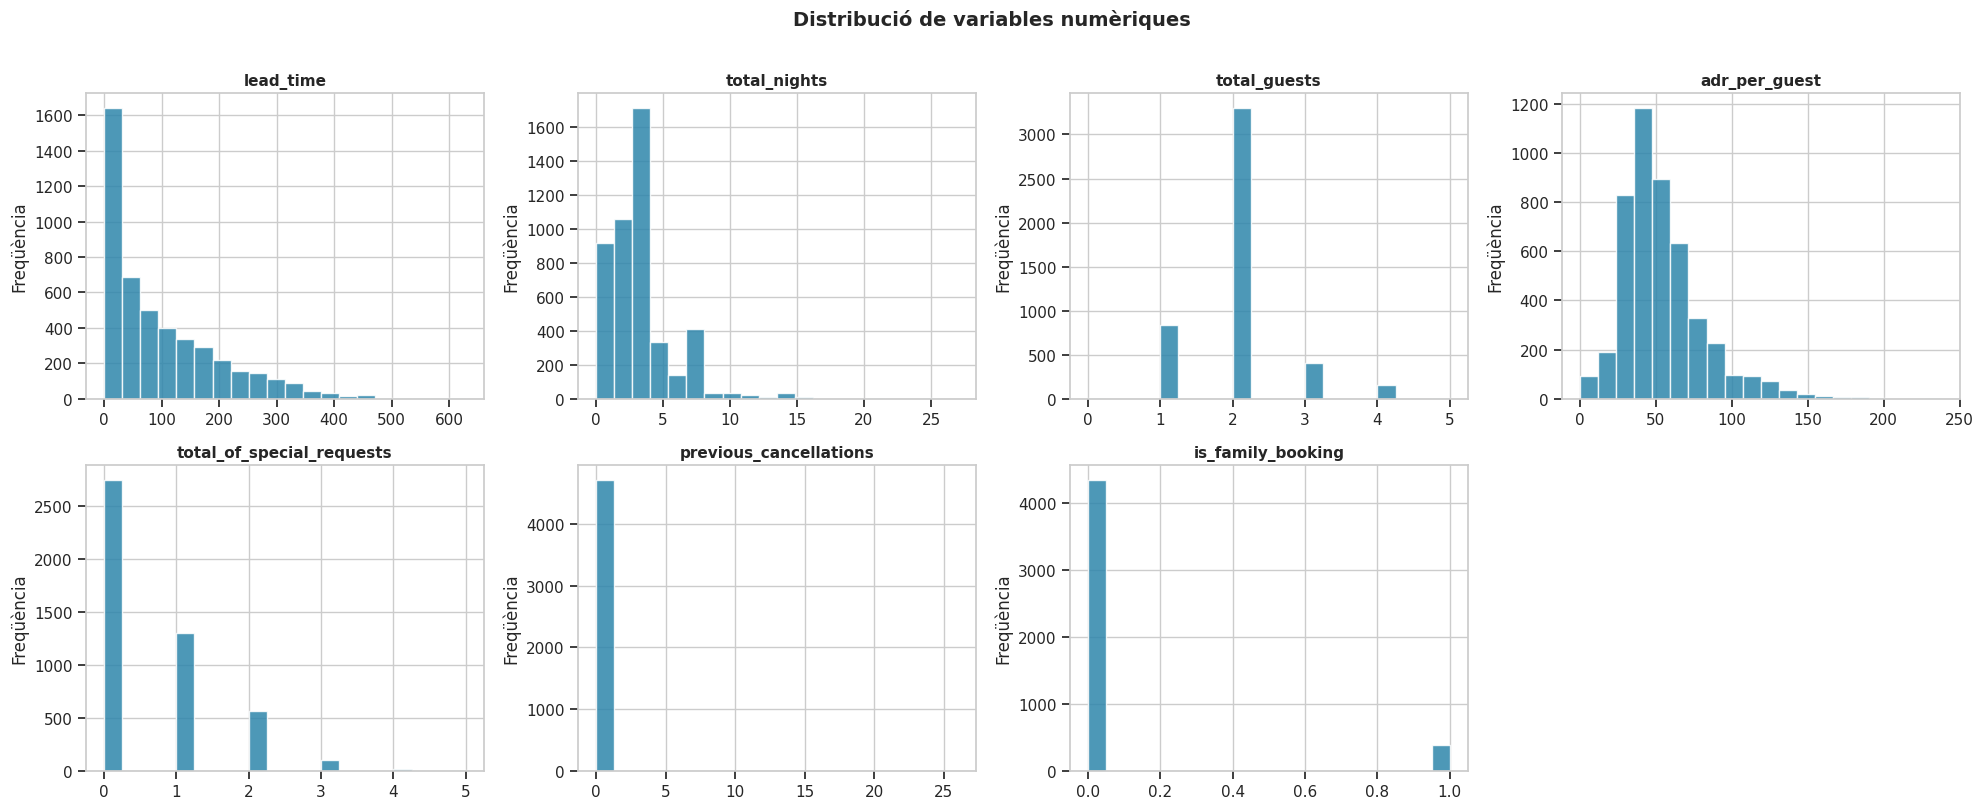

In [25]:
num_cols = [
    "lead_time",
    "total_nights",
    "total_guests",
    "adr_per_guest",
    "total_of_special_requests",
    "previous_cancellations",
    "is_family_booking",
]

available_num_cols = [col for col in num_cols if col in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, available_num_cols):
    ax.hist(df[col].dropna(), bins=20, color=PALETTE[0], edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Freqüència")

for ax in axes[len(available_num_cols):]:
    ax.axis("off")

plt.suptitle("Distribució de variables numèriques", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

També es revisa la composició de les principals variables categòriques per entendre l'estructura de la cartera de reserves.


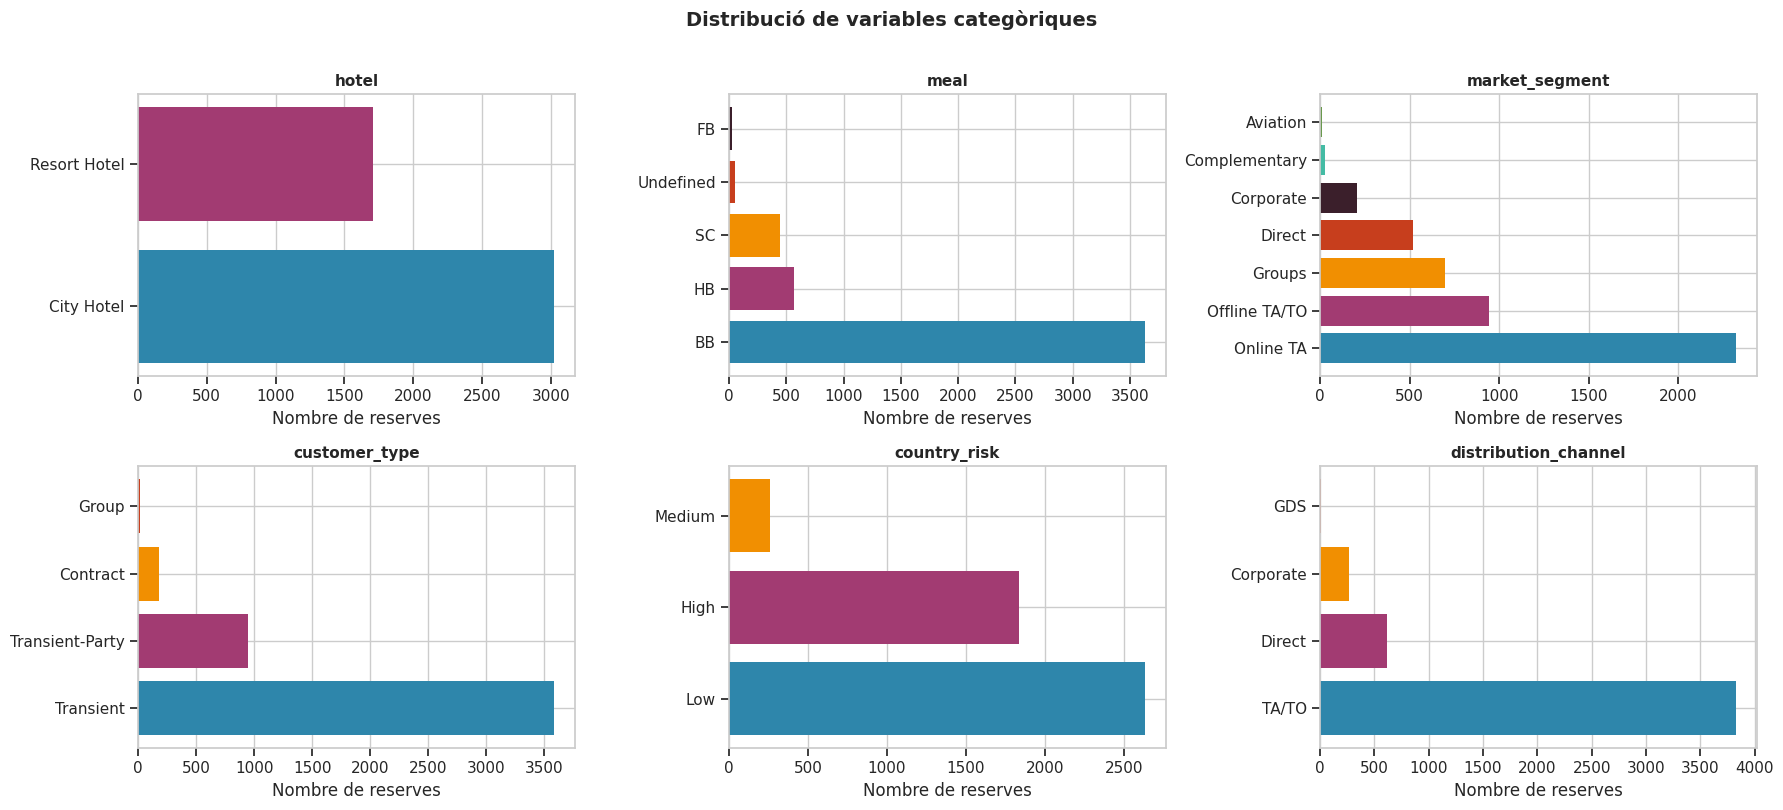

In [26]:
cat_cols = ["hotel", "meal", "market_segment", "customer_type", "country_risk", "distribution_channel"]
available_cat_cols = [col for col in cat_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, available_cat_cols):
    counts = df[col].fillna("No informat").value_counts()
    colors = PALETTE[: len(counts)] if len(counts) <= len(PALETTE) else None
    ax.barh(counts.index.astype(str), counts.values, color=colors)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nombre de reserves")

for ax in axes[len(available_cat_cols):]:
    ax.axis("off")

plt.suptitle("Distribució de variables categòriques", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Preparació de variables per al clustering

Es construeix una matriu de variables enfocada en el comportament de reserva. Les variables categòriques es codifiquen de manera senzilla per mantenir una interpretació directa del perfil resultant.

La variable derivada `spend_total` s'utilitza només per al càlcul del clustering i per a la interpretació del perfil, però no s'afegeix al fitxer final exportat.


In [27]:
def require_columns(dataframe, required_columns):
    missing = [col for col in required_columns if col not in dataframe.columns]
    if missing:
        raise ValueError(f"Falten columnes necessàries per al clustering: {missing}")

required_columns = [
    "lead_time",
    "total_nights",
    "total_guests",
    "adr_per_guest",
    "total_of_special_requests",
    "is_family_booking",
    "previous_cancellations",
    "has_agent",
    "is_repeated_guest",
    "hotel",
    "meal",
    "market_segment",
    "customer_type",
    "country_risk",
]

require_columns(df, required_columns)

df_model = df.copy()

# Variables numèriques directes.
numeric_features = [
    "lead_time",
    "total_nights",
    "total_guests",
    "adr_per_guest",
    "total_of_special_requests",
    "is_family_booking",
    "previous_cancellations",
    "has_agent",
    "is_repeated_guest",
]

# Codificació simple de variables categòriques.
df_model["is_resort"] = (df_model["hotel"] == "Resort Hotel").astype(int)

meal_map = {"Undefined": 0, "SC": 1, "BB": 2, "HB": 3, "FB": 4}
segment_map = {"Groups": 0, "Corporate": 1, "Offline TA/TO": 2, "Direct": 3, "Online TA": 4}
customer_type_map = {"Contract": 0, "Group": 1, "Transient-Party": 2, "Transient": 3}
country_risk_map = {"Low": 0, "Medium": 1, "High": 2}

df_model["meal_enc"] = df_model["meal"].map(meal_map).fillna(1)
df_model["segment_enc"] = df_model["market_segment"].map(segment_map).fillna(2)
df_model["customer_type_enc"] = df_model["customer_type"].map(customer_type_map).fillna(3)
df_model["country_risk_enc"] = df_model["country_risk"].map(country_risk_map).fillna(0)

# Variable econòmica derivada per segmentar segons el valor de la reserva.
df_model["spend_total"] = (
    df_model["adr_per_guest"] * df_model["total_guests"] * df_model["total_nights"]
)

# Variable de complexitat de reserva.
df_model["booking_complexity"] = (
    df_model["total_of_special_requests"] + df_model["is_family_booking"]
)

FEATURES = numeric_features + [
    "is_resort",
    "meal_enc",
    "segment_enc",
    "customer_type_enc",
    "country_risk_enc",
    "spend_total",
    "booking_complexity",
]

X_raw = df_model[FEATURES].copy()

# Correcció bàsica de valors econòmics nuls o iguals a zero.
for col in ["adr_per_guest", "spend_total"]:
    median_value = X_raw.loc[X_raw[col] > 0, col].median()
    X_raw[col] = X_raw[col].where(X_raw[col] > 0, median_value)

X_raw = X_raw.fillna(X_raw.median(numeric_only=True))

print(f"Nombre de variables utilitzades en el clustering: {len(FEATURES)}")
display(pd.DataFrame({"feature": FEATURES}))

Nombre de variables utilitzades en el clustering: 16


,feature
0,lead_time
1,total_nights
2,total_guests
3,adr_per_guest
4,total_of_special_requests
5,is_family_booking
6,previous_cancellations
7,has_agent
8,is_repeated_guest
9,is_resort


## 6. Estandardització i PCA

Les variables s'estandarditzen abans d'aplicar els models de clustering. El PCA s'utilitza únicament com a eina de visualització i diagnòstic, no com a substitut directe de la matriu completa de clustering.


Variància explicada pel PCA 2D: 31.84%
Variància explicada pel PCA 3D: 41.89%


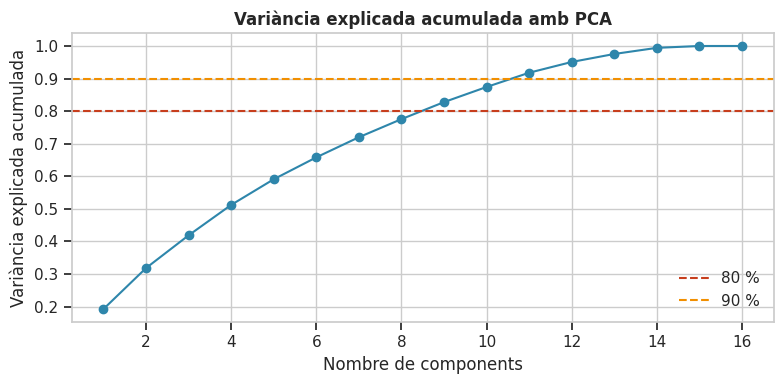

In [28]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X)

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3d.fit_transform(X)

print(f"Variància explicada pel PCA 2D: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"Variància explicada pel PCA 3D: {pca_3d.explained_variance_ratio_.sum():.2%}")

pca_full = PCA(random_state=RANDOM_STATE).fit(X)
explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o", color=PALETTE[0])
ax.axhline(0.80, linestyle="--", color=PALETTE[3], label="80 %")
ax.axhline(0.90, linestyle="--", color=PALETTE[2], label="90 %")
ax.set_xlabel("Nombre de components")
ax.set_ylabel("Variància explicada acumulada")
ax.set_title("Variància explicada acumulada amb PCA", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Selecció del nombre de clústers

S'avaluen diferents valors de `K` mitjançant quatre mètriques internes:

- Inèrcia: ha de reduir-se en augmentar `K`, buscant un punt de colze.
- Silhouette: els valors més alts indiquen clústers més compactes i separats.
- Davies-Bouldin: els valors més baixos indiquen una millor separació relativa.
- Calinski-Harabasz: els valors més alts indiquen una millor definició dels grups.

La selecció automàtica prioritza Silhouette, tot i que la decisió final s'ha de comprovar amb la interpretabilitat dels perfils.


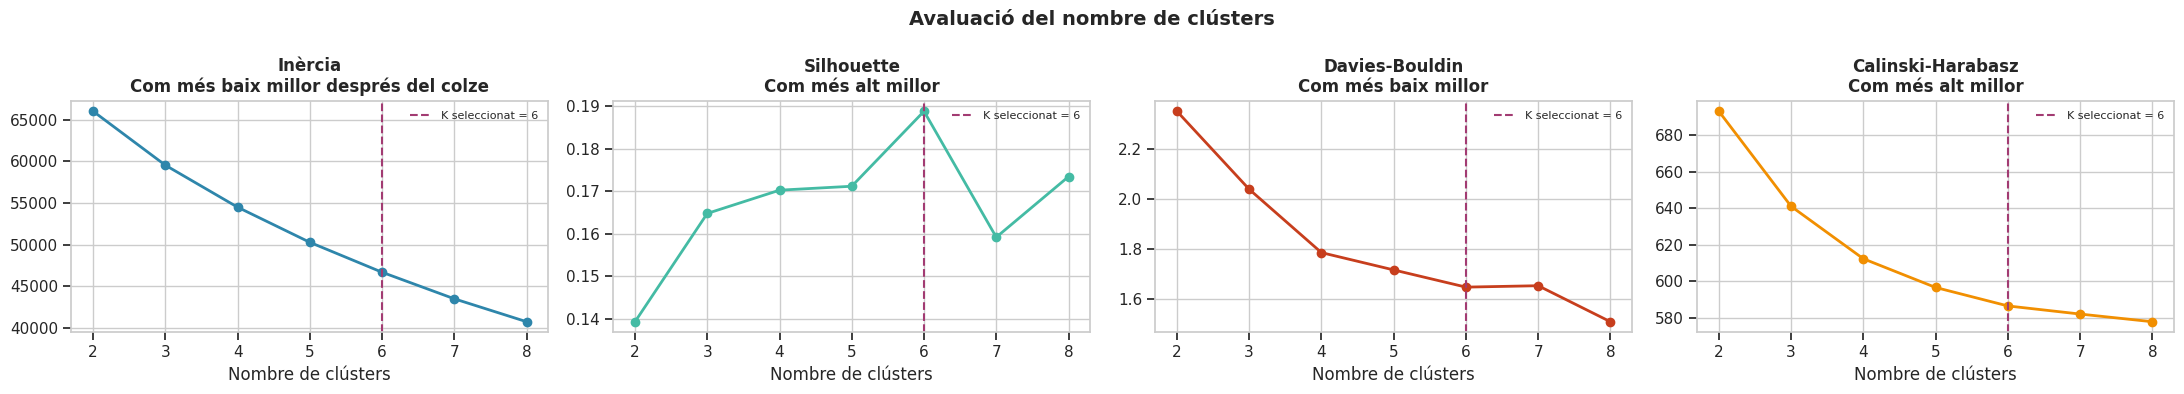

,K,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,66003.2203,0.1393,2.3527,693.1766
1,3,59533.2970,0.1648,2.0401,641.0325
2,4,54498.5606,0.1702,1.7862,612.2708
3,5,50285.8133,0.1712,1.7168,596.5286
4,6,46697.2989,0.1888,1.6479,586.3906
5,7,43512.2006,0.1592,1.6535,581.9390
6,8,40766.2399,0.1734,1.5092,577.7287


K seleccionat segons Silhouette: 6


In [29]:
K_RANGE = range(2, 9)
metric_rows = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, n_init=30, max_iter=500, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    metric_rows.append({
        "K": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    })

metrics_df = pd.DataFrame(metric_rows)
best_k = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "K"])

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
plots = [
    ("inertia", "Inèrcia", "Com més baix millor després del colze", PALETTE[0]),
    ("silhouette", "Silhouette", "Com més alt millor", PALETTE[5]),
    ("davies_bouldin", "Davies-Bouldin", "Com més baix millor", PALETTE[3]),
    ("calinski_harabasz", "Calinski-Harabasz", "Com més alt millor", PALETTE[2]),
]

for ax, (column, title, subtitle, color) in zip(axes, plots):
    ax.plot(metrics_df["K"], metrics_df[column], marker="o", linewidth=2, color=color)
    ax.axvline(best_k, linestyle="--", color=PALETTE[1], label=f"K seleccionat = {best_k}")
    ax.set_title(f"{title}\n{subtitle}", fontweight="bold")
    ax.set_xlabel("Nombre de clústers")
    ax.set_xticks(list(K_RANGE))
    ax.legend(fontsize=8)

plt.suptitle("Avaluació del nombre de clústers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

display(metrics_df.round(4))
print(f"K seleccionat segons Silhouette: {best_k}")

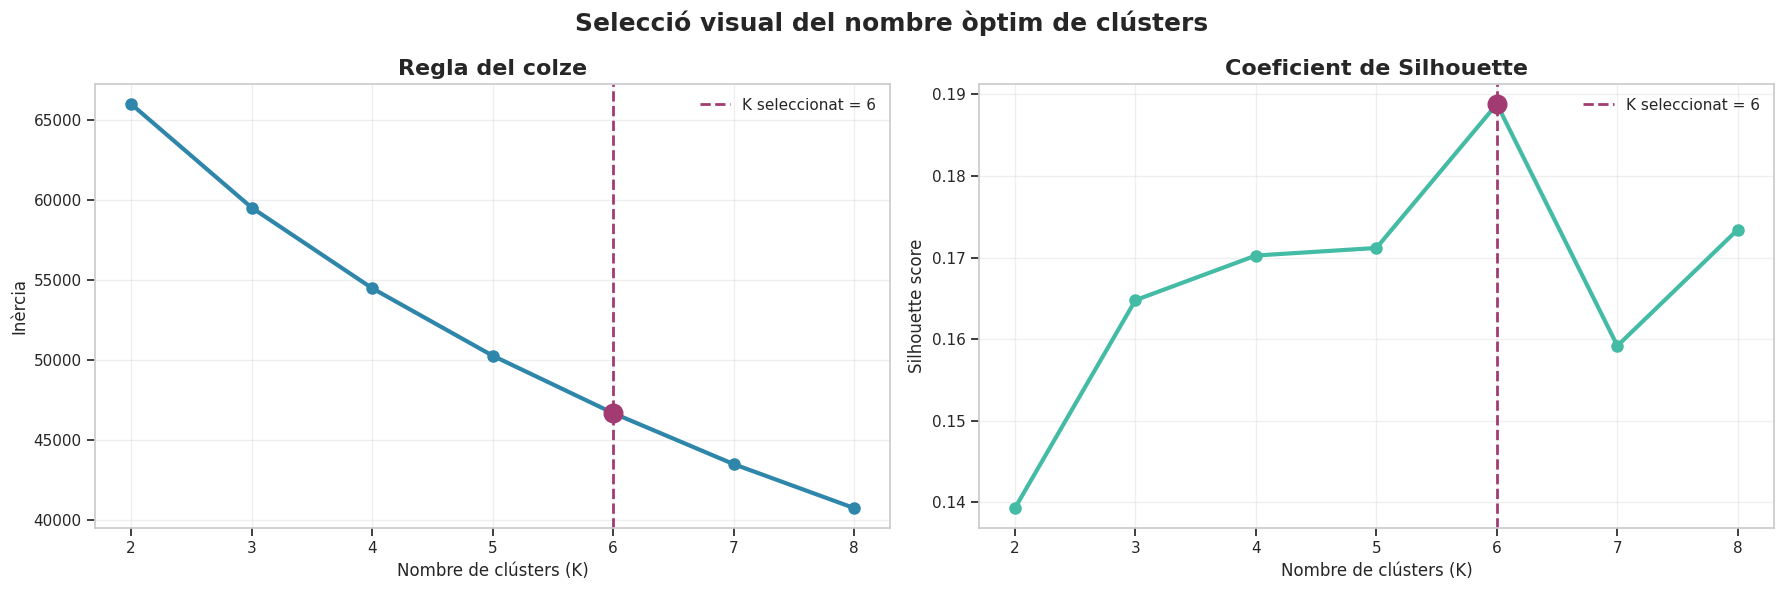

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gràfic 1: regla del colze
axes[0].plot(
    metrics_df["K"],
    metrics_df["inertia"],
    marker="o",
    linewidth=3,
    markersize=8,
    color=PALETTE[0]
)

axes[0].axvline(
    best_k,
    linestyle="--",
    linewidth=2,
    color=PALETTE[1],
    label=f"K seleccionat = {best_k}"
)

axes[0].scatter(
    best_k,
    metrics_df.loc[metrics_df["K"] == best_k, "inertia"],
    s=180,
    color=PALETTE[1],
    zorder=5
)

axes[0].set_title("Regla del colze", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Nombre de clústers (K)", fontsize=12)
axes[0].set_ylabel("Inèrcia", fontsize=12)
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=11)

# Gràfic 2: Silhouette
axes[1].plot(
    metrics_df["K"],
    metrics_df["silhouette"],
    marker="o",
    linewidth=3,
    markersize=8,
    color=PALETTE[5]
)

axes[1].axvline(
    best_k,
    linestyle="--",
    linewidth=2,
    color=PALETTE[1],
    label=f"K seleccionat = {best_k}"
)

axes[1].scatter(
    best_k,
    metrics_df.loc[metrics_df["K"] == best_k, "silhouette"],
    s=180,
    color=PALETTE[1],
    zorder=5
)

axes[1].set_title("Coeficient de Silhouette", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Nombre de clústers (K)", fontsize=12)
axes[1].set_ylabel("Silhouette score", fontsize=12)
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=11)

plt.suptitle(
    "Selecció visual del nombre òptim de clústers",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 8. Comparació de models de clustering

Es comparen tres models amb el mateix nombre de clústers seleccionat: K-Means, clustering jeràrquic amb enllaç Ward i Gaussian Mixture Model. L'elecció del model final es fa mitjançant Silhouette i després es valida amb la interpretació dels perfils.


In [31]:
K = best_k

models = {
    "KMeans": KMeans(n_clusters=K, n_init=30, max_iter=500, random_state=RANDOM_STATE),
    "Jeràrquic": AgglomerativeClustering(n_clusters=K, linkage="ward"),
    "GMM": GaussianMixture(n_components=K, covariance_type="full", random_state=RANDOM_STATE),
}

results = {}
for model_name, model in models.items():
    labels = model.fit_predict(X)
    results[model_name] = {
        "labels": labels,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }

comparison_df = pd.DataFrame(results).T
best_model_name = comparison_df["silhouette"].idxmax()
best_labels = results[best_model_name]["labels"]

print(f"Model seleccionat: {best_model_name}")
display(comparison_df.round(4))

Model seleccionat: GMM


,labels,silhouette,davies_bouldin,calinski_harabasz
KMeans,"[2, 4, 4, 4, 4, 4, 4, 0, 2, 0, 4, 4, 2, 0, 0, ...",0.188804,1.647872,586.390575
Jeràrquic,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, ...",0.172303,1.52878,503.603147
GMM,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, ...",0.19727,1.764726,411.920389


## 9. Visualització comparativa dels models

Es projecta cada solució de clustering sobre els dos primers components principals per comparar-ne visualment la separació.


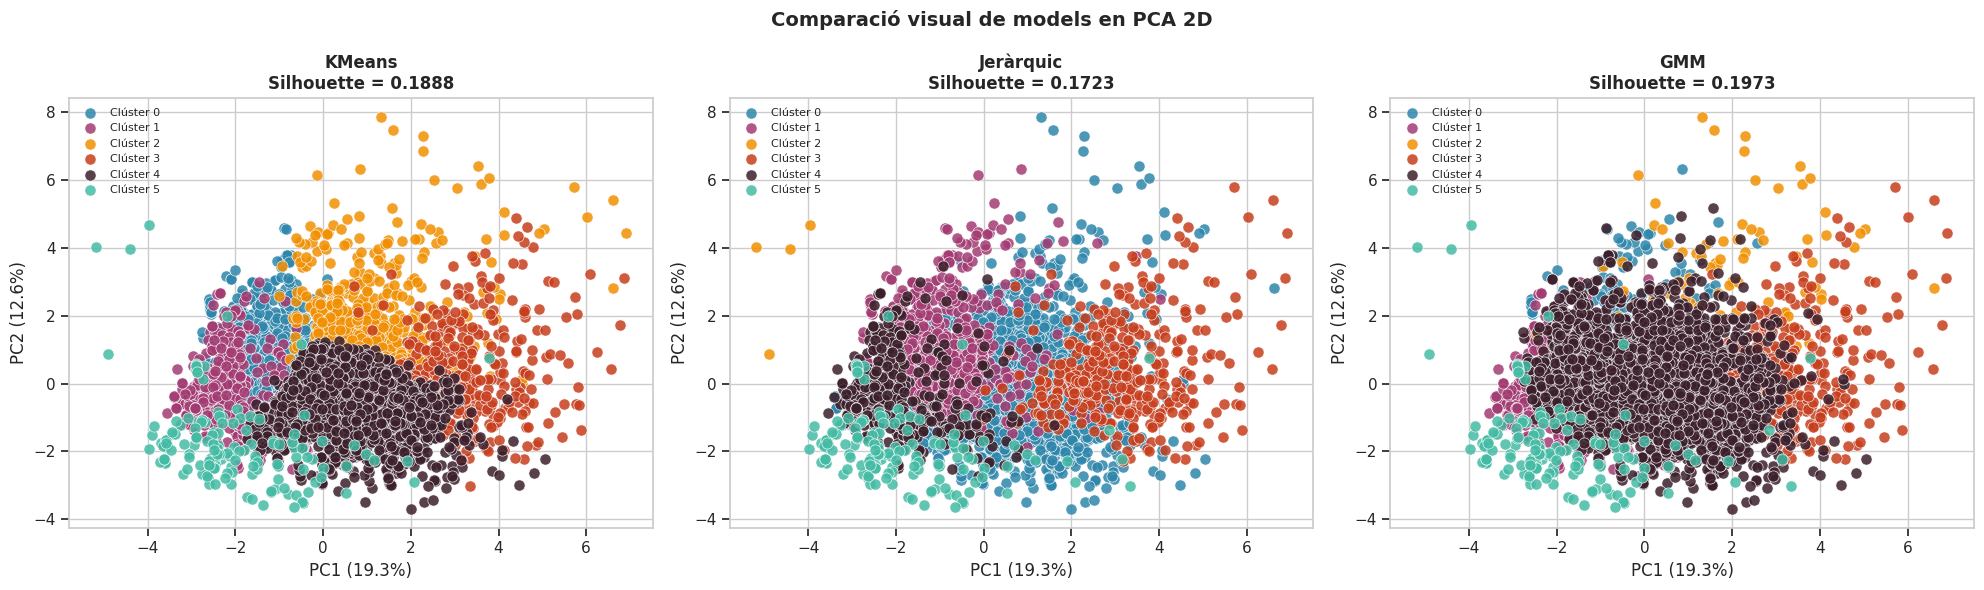

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model_name, result) in zip(axes, results.items()):
    labels = result["labels"]
    for cluster_id in sorted(np.unique(labels)):
        mask = labels == cluster_id
        ax.scatter(
            X_pca2[mask, 0],
            X_pca2[mask, 1],
            s=65,
            alpha=0.85,
            color=PALETTE[int(cluster_id) % len(PALETTE)],
            edgecolors="white",
            linewidths=0.5,
            label=f"Clúster {cluster_id}",
        )
    ax.set_title(f"{model_name}\nSilhouette = {result['silhouette']:.4f}", fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
    ax.legend(fontsize=8)

plt.suptitle("Comparació visual de models en PCA 2D", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Dendrograma del clustering jeràrquic

El dendrograma s'inclou com a suport visual per observar l'estructura jeràrquica dels grups. Per evitar una figura massa saturada, es representa una mostra si el dataset és gran.


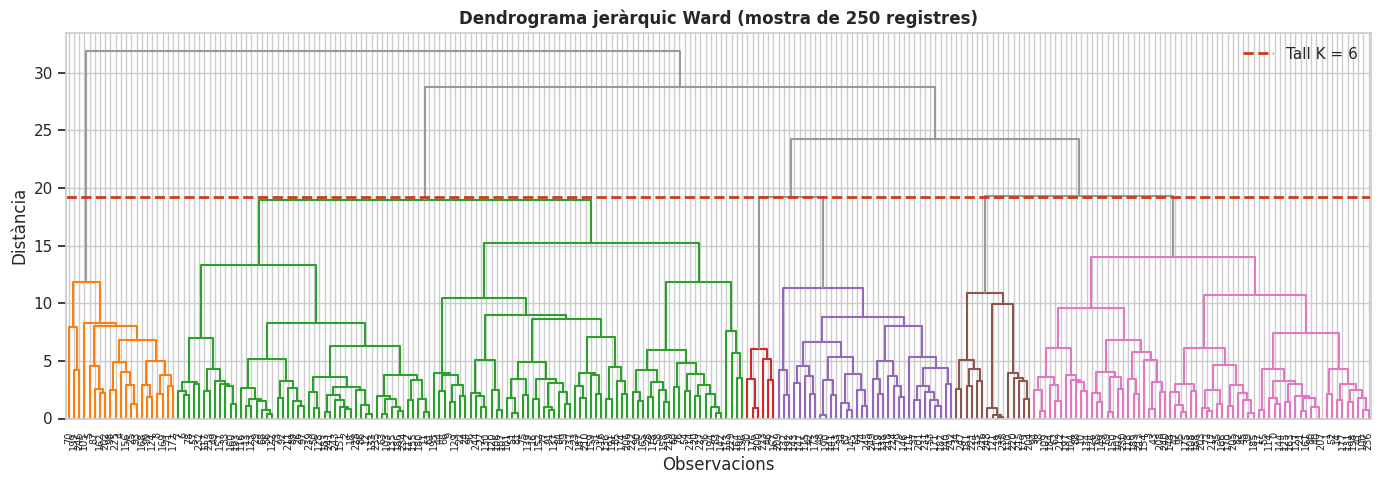

In [33]:
max_dendrogram_points = 250
if X.shape[0] > max_dendrogram_points:
    sample_idx = np.random.choice(X.shape[0], size=max_dendrogram_points, replace=False)
    X_dendrogram = X[sample_idx]
    title_suffix = f"mostra de {max_dendrogram_points} registres"
else:
    X_dendrogram = X
    title_suffix = "dataset complet"

Z = linkage(X_dendrogram, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    ax=ax,
    color_threshold=Z[-K + 1, 2] if K > 1 else None,
    above_threshold_color="#999999",
    leaf_rotation=90,
    leaf_font_size=7,
)
if K > 1:
    ax.axhline(Z[-K + 1, 2], linestyle="--", linewidth=2, color=PALETTE[3], label=f"Tall K = {K}")
    ax.legend()
ax.set_title(f"Dendrograma jeràrquic Ward ({title_suffix})", fontweight="bold")
ax.set_xlabel("Observacions")
ax.set_ylabel("Distància")
plt.tight_layout()
plt.show()

## 11. Assignació final de clústers

S'afegeix l'assignació del model seleccionat a una còpia de treball. Aquesta columna serà l'única que s'afegirà al fitxer final exportat.


In [34]:
df_model["cluster"] = best_labels.astype(int)

cluster_distribution = (
    df_model["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="n_reserves")
)
cluster_distribution["percentatge"] = (cluster_distribution["n_reserves"] / len(df_model) * 100).round(2)

display(cluster_distribution)

,cluster,n_reserves,percentatge
0,0,326,6.89
1,1,502,10.61
2,2,78,1.65
3,3,383,8.10
4,4,3280,69.34
5,5,161,3.40


## 12. Perfil numèric dels clústers

Es calculen mitjanes per clúster per interpretar el tipus de reserva predominant en cada grup.


In [35]:
profile_num = [
    "lead_time",
    "total_nights",
    "total_guests",
    "adr_per_guest",
    "total_of_special_requests",
    "spend_total",
    "is_family_booking",
    "previous_cancellations",
    "is_repeated_guest",
]

cluster_profile_num = df_model.groupby("cluster")[profile_num].mean().round(2)
display(cluster_profile_num)

,lead_time,total_nights,total_guests,adr_per_guest,total_of_special_requests,spend_total,is_family_booking,previous_cancellations,is_repeated_guest
cluster,,,,,,,,,
0,159.83,3.88,1.89,44.87,0.40,314.01,0.00,0.54,0.00
1,57.77,2.30,1.57,55.84,0.20,194.71,0.00,0.03,0.00
2,147.26,12.72,1.97,67.88,0.92,1501.17,0.03,0.03,0.00
3,89.64,3.86,3.39,45.09,0.85,595.11,1.00,0.00,0.00
4,104.61,3.35,1.91,55.80,0.63,339.48,0.00,0.00,0.00
5,33.34,1.66,1.51,46.47,0.65,120.76,0.03,0.96,0.98


## 13. Perfil categòric dels clústers

S'analitza la distribució relativa de les variables categòriques principals dins de cada clúster.


In [36]:
for col in ["hotel", "meal", "market_segment", "customer_type", "country_risk", "distribution_channel"]:
    if col in df_model.columns:
        print(f"Distribució de {col} per clúster (%)")
        crosstab = pd.crosstab(df_model["cluster"], df_model[col], normalize="index") * 100
        display(crosstab.round(1))

Distribució de hotel per clúster (%)


hotel,City Hotel,Resort Hotel
cluster,,
0,66.0,34.0
1,44.8,55.2
2,7.7,92.3
3,62.7,37.3
4,68.8,31.2
5,50.9,49.1


Distribució de meal per clúster (%)


meal,BB,FB,HB,SC,Undefined
cluster,,,,,
0,74.2,0.6,15.0,3.1,7.1
1,89.6,0.6,5.2,2.2,2.4
2,51.3,0.0,38.5,1.3,9.0
3,82.0,1.3,14.4,1.8,0.5
4,74.5,0.5,12.3,12.6,0.2
5,87.6,0.6,5.0,5.0,1.9


Distribució de market_segment per clúster (%)


...

customer_type,Contract,Group,Transient,Transient-Party
cluster,,,,
0,49.7,1.8,27.3,21.2
1,0.0,0.8,65.7,33.5
2,14.1,0.0,73.1,12.8
3,1.8,0.0,91.1,7.0
4,0.0,0.1,80.0,19.9
5,0.0,3.7,82.6,13.7


Distribució de country_risk per clúster (%)


country_risk,High,Low,Medium
cluster,,,
0,65.6,33.1,1.2
1,61.8,37.1,1.2
2,42.3,53.8,3.8
3,31.3,60.8,7.8
4,31.2,62.3,6.6
5,83.9,13.7,2.5


Distribució de distribution_channel per clúster (%)


distribution_channel,Corporate,Direct,GDS,TA/TO
cluster,,,,
0,0.9,0.9,0.0,98.2
1,32.5,48.2,0.0,19.3
2,5.1,15.4,0.0,79.5
3,0.3,21.4,0.0,78.3
4,1.0,7.2,0.4,91.5
5,41.0,28.0,0.0,31.1


## 14. Radar de perfils

El gràfic radar resumeix les característiques mitjanes normalitzades de cada clúster. Serveix per comparar ràpidament els trets dominants de cada perfil.


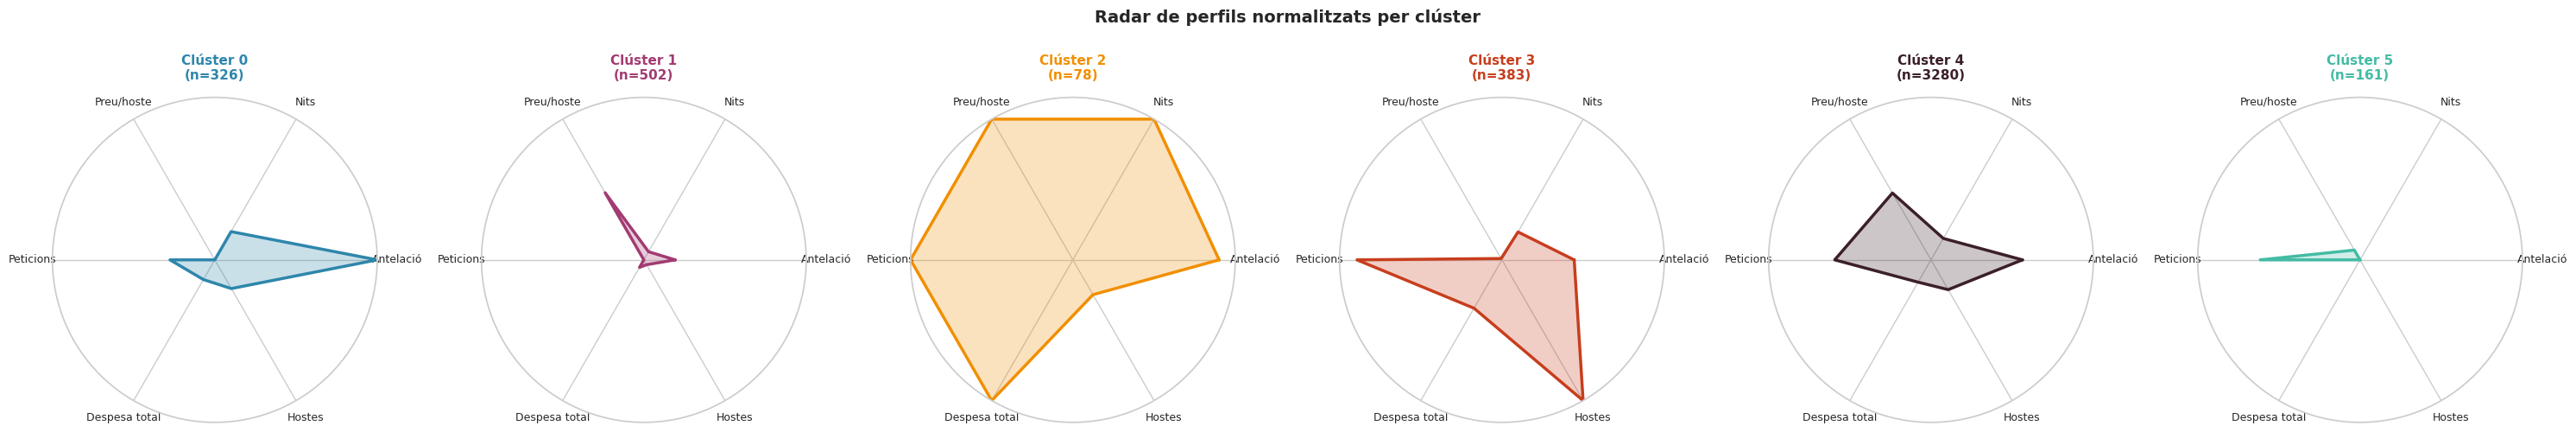

In [37]:
radar_cols = [
    "lead_time",
    "total_nights",
    "adr_per_guest",
    "total_of_special_requests",
    "spend_total",
    "total_guests",
]
radar_labels = ["Antelació", "Nits", "Preu/hoste", "Peticions", "Despesa total", "Hostes"]

cluster_means = df_model.groupby("cluster")[radar_cols].mean().sort_index()
cluster_means_norm = (
    (cluster_means - cluster_means.min()) /
    (cluster_means.max() - cluster_means.min() + 1e-9)
)

num_vars = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K, figsize=(5 * K, 5), subplot_kw={"polar": True})
if K == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_means_norm.index):
    values = cluster_means_norm.loc[cluster_id].tolist()
    values += values[:1]
    color = PALETTE[int(cluster_id) % len(PALETTE)]
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(
        f"Clúster {cluster_id}\n(n={(df_model['cluster'] == cluster_id).sum()})",
        fontsize=11,
        fontweight="bold",
        color=color,
        pad=15,
    )

plt.suptitle("Radar de perfils normalitzats per clúster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 15. Matriu TLP de perfils normalitzats

En lloc d'un mapa de calor clàssic, s'utilitza una visualització tipus semàfor TLP. Els valors normalitzats es codifiquen en verd, groc, taronja i vermell per destacar de manera immediata quines variables són baixes, mitjanes, altes o molt altes en cada clúster.


In [60]:
import matplotlib
from matplotlib.colors import LinearSegmentedColormap, to_rgb, to_hex
import numpy as np
import pandas as pd

selected_vars = [
    "lead_time", "total_nights", "total_guests", "is_family_booking",
    "adr_per_guest", "spend_total", "total_of_special_requests",
    "previous_cancellations", "is_repeated_guest",
    "market_segment", "distribution_channel", "country_risk",
]
selected_vars = [v for v in selected_vars if v in df_model.columns]

numeric_vars   = [v for v in selected_vars if pd.api.types.is_numeric_dtype(df_model[v])]
categorical_vars = [v for v in selected_vars if v not in numeric_vars]

variable_labels = {
    "lead_time": "Antelació", "total_nights": "Nits totals",
    "total_guests": "Hostes", "is_family_booking": "Reserva familiar",
    "adr_per_guest": "Preu per hoste", "spend_total": "Despesa total",
    "total_of_special_requests": "Peticions especials",
    "previous_cancellations": "Cancel·lacions prèvies",
    "is_repeated_guest": "Client repetidor",
    "market_segment": "Segment de mercat",
    "distribution_channel": "Canal de distribució",
    "country_risk": "Risc del país",
}

# "high" = valor alt del clúster és bo | "low" = valor baix és bo
numeric_polarity = {
    "lead_time": "high", "total_nights": "high", "total_guests": "high",
    "is_family_booking": "high", "adr_per_guest": "high", "spend_total": "high",
    "total_of_special_requests": "low", "previous_cancellations": "low",
    "is_repeated_guest": "high",
}

categorical_scores = {
    "market_segment": {
        "Direct": 1.00, "Corporate": 0.90, "Groups": 0.60,
        "Complementary": 0.45, "Aviation": 0.40,
        "Online TA": 0.35, "Offline TA/TO": 0.25, "Undefined": 0.00,
    },
    "distribution_channel": {
        "Direct": 1.00, "Corporate": 0.85, "GDS": 0.60,
        "TA/TO": 0.25, "Undefined": 0.00,
    },
    "country_risk": {"Low": 1.00, "Medium": 0.55, "High": 0.00},
}

traffic_cmap = LinearSegmentedColormap.from_list(
    "traffic_semantic", ["#C62828", "#FB8C00", "#FDD835", "#2E7D32"], N=256
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def to_hex(color): return matplotlib.colors.to_hex(color)

def blend_with_white(hex_color, strength):
    strength = np.clip(strength, 0, 1)
    rgb = np.array(to_rgb(hex_color))
    return matplotlib.colors.to_hex(np.array([1,1,1]) * (1 - strength) + rgb * strength)

def text_color_from_hex(hex_color):
    r, g, b = to_rgb(hex_color)
    return "white" if 0.299*r + 0.587*g + 0.114*b < 0.48 else "#1f1f1f"

def mode_value(series):
    m = series.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

def category_score(var, value):
    return categorical_scores.get(var, {}).get(value, 0.50)

# ── Càlcul inter-clúster (clau de la correcció) ───────────────────────────────
cluster_order = sorted(df_model["cluster"].unique())

# Pas 1: calcula la mitjana de cada clúster per cada variable numèrica
cluster_means_dict = {
    var: {cid: df_model[df_model["cluster"] == cid][var].mean()
          for cid in cluster_order}
    for var in numeric_vars
}

def intercluster_score(var, cluster_id):
    """
    Converteix la mitjana del clúster en un score 0-1 comparant-la
    contra la distribució de mitjanes de TOTS els clústers.
    Així, variables binàries com is_repeated_guest sí discriminen.
    """
    means = np.array(list(cluster_means_dict[var].values()))
    val   = cluster_means_dict[var][cluster_id]
    
    mn, mx = means.min(), means.max()
    if mx == mn:
        # Tots els clústers iguals → score neutre
        return 0.50
    
    # Posició relativa dins del rang inter-clúster
    raw_score = (val - mn) / (mx - mn)
    
    if numeric_polarity.get(var, "high") == "low":
        return 1.0 - raw_score
    return raw_score

# ── Construcció d'atlp_df ─────────────────────────────────────────────────────
rows = []

for cluster_id in cluster_order:
    subset = df_model[df_model["cluster"] == cluster_id]

    for var in selected_vars:
        label = variable_labels.get(var, var)

        if var in numeric_vars:
            cluster_mean = subset[var].mean()

            # Score inter-clúster (discrimina fins i tot variables binàries)
            semantic_score = intercluster_score(var, cluster_id)

            base_color  = matplotlib.colors.to_hex(traffic_cmap(np.clip(semantic_score, 0, 1)))

            # Puresa: cohesió interna del clúster per aquesta variable
            global_std  = df_model[var].std()
            cluster_std = subset[var].std()
            if pd.isna(global_std) or global_std == 0 or pd.isna(cluster_std):
                purity = 0.70
            else:
                purity = np.clip(1 - min(cluster_std / global_std, 1.5) / 1.5, 0.25, 1.00)

            atlp_color = blend_with_white(base_color, purity)

            rows.append({
                "cluster": cluster_id, "variable": var,
                "variable_label": label, "type": "numeric",
                "score": semantic_score, "purity": purity,
                "display_text": f"{cluster_mean:.2f}",
                "base_color": base_color, "atlp_color": atlp_color,
            })

        else:
            mode      = mode_value(subset[var])
            dominance = float((subset[var] == mode).mean()) if not pd.isna(mode) else 0.0
            mode_text = str(mode) if not pd.isna(mode) else "NA"

            semantic_score = category_score(var, mode)
            base_color     = matplotlib.colors.to_hex(traffic_cmap(np.clip(semantic_score, 0, 1)))
            purity         = np.clip(dominance, 0.25, 1.00)
            atlp_color     = blend_with_white(base_color, purity)

            rows.append({
                "cluster": cluster_id, "variable": var,
                "variable_label": label, "type": "categorical",
                "score": semantic_score, "purity": purity,
                "display_text": f"{mode_text}\n{dominance:.0%}",
                "base_color": base_color, "atlp_color": atlp_color,
            })

atlp_df = pd.DataFrame(rows)

display(
    atlp_df[["cluster", "variable_label", "type", "score", "purity", "display_text"]]
    .sort_values(["cluster", "variable_label"])
    .reset_index(drop=True)
)

,cluster,variable_label,type,score,purity,display_text
0,0,Antelació,numeric,1.000000,0.250000,159.83
1,0,Canal de distribució,categorical,0.250000,0.981595,TA/TO\n98%
2,0,Cancel·lacions prèvies,numeric,0.432376,0.517862,0.54
3,0,Client repetidor,numeric,0.000000,1.000000,0.00
4,0,Despesa total,numeric,0.139999,0.516012,314.01
...,...,...,...,...,...,...
67,5,Peticions especials,numeric,0.384940,0.272577,0.65
68,5,Preu per hoste,numeric,0.069538,0.250000,46.47
69,5,Reserva familiar,numeric,0.031056,0.578283,0.03
70,5,Risc del país,categorical,0.000000,0.838509,High\n84%


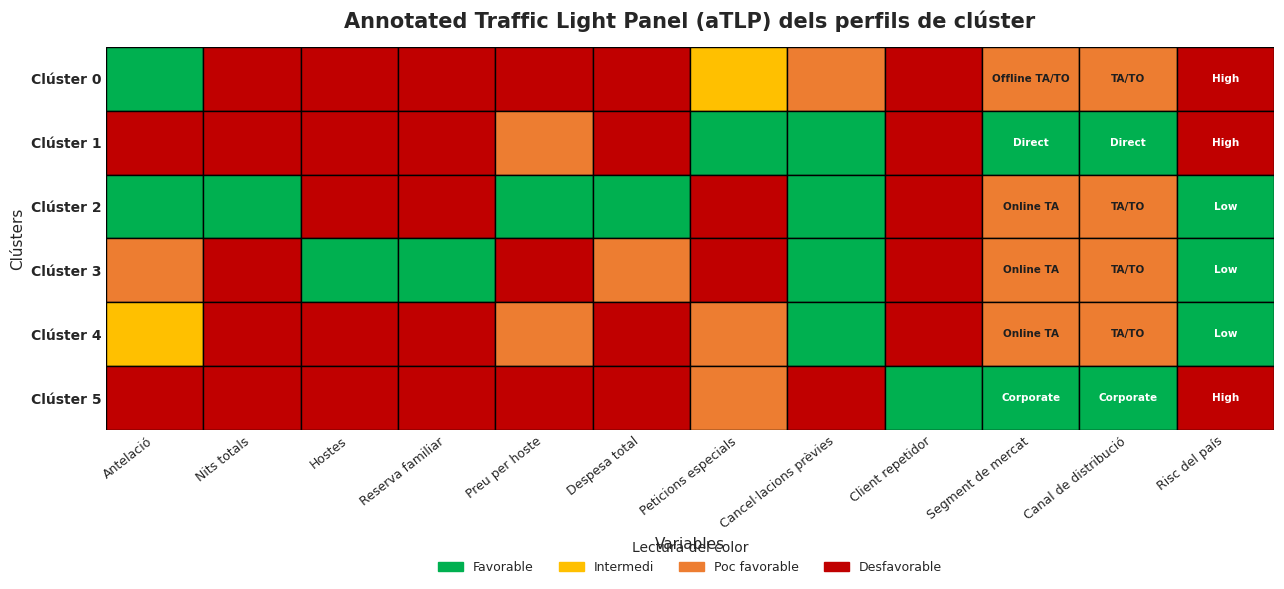

In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plot_df = atlp_df.copy()

# Colors forts i llegibles
semantic_colors = {
    "favorable": "#00B050",       # verd intens
    "intermedi": "#FFC000",       # groc potent
    "poc_favorable": "#ED7D31",   # taronja potent
    "desfavorable": "#C00000",    # vermell intens
}

def score_to_color(score):
    if score >= 0.75:
        return semantic_colors["favorable"]
    elif score >= 0.50:
        return semantic_colors["intermedi"]
    elif score >= 0.25:
        return semantic_colors["poc_favorable"]
    else:
        return semantic_colors["desfavorable"]

def score_to_label(score):
    if score >= 0.75:
        return "Favorable"
    elif score >= 0.50:
        return "Intermedi"
    elif score >= 0.25:
        return "Poc favorable"
    else:
        return "Desfavorable"

def only_modality(text):
    return str(text).split("\n")[0]

plot_df["panel_color"] = plot_df["score"].apply(score_to_color)
plot_df["semantic_level"] = plot_df["score"].apply(score_to_label)

x_vars = selected_vars
x_labels = [variable_labels.get(v, v) for v in x_vars]
y_clusters = cluster_order

categorical_vars_plot = {"market_segment", "distribution_channel", "country_risk"}

fig_width = max(13, 0.95 * len(x_vars))
fig_height = max(4.8, 0.72 * len(y_clusters) + 2.0)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for _, row in plot_df.iterrows():
    x = x_vars.index(row["variable"])
    y = y_clusters.index(row["cluster"])
    color = row["panel_color"]

    rect = plt.Rectangle(
        (x - 0.5, y - 0.5),
        1,
        1,
        facecolor=color,
        edgecolor="black",
        linewidth=1.0
    )
    ax.add_patch(rect)

    # Només mostrar la modalitat a les variables categòriques
    if row["variable"] in categorical_vars_plot:
        ax.text(
            x,
            y,
            only_modality(row["display_text"]),
            ha="center",
            va="center",
            fontsize=7.5,
            fontweight="bold",
            color=text_color_from_hex(color),
        )

ax.set_xlim(-0.5, len(x_vars) - 0.5)
ax.set_ylim(len(y_clusters) - 0.5, -0.5)

ax.set_xticks(range(len(x_vars)))
ax.set_xticklabels(
    x_labels,
    rotation=38,
    ha="right",
    fontsize=9
)

ax.set_yticks(range(len(y_clusters)))
ax.set_yticklabels(
    [f"Clúster {c}" for c in y_clusters],
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Annotated Traffic Light Panel (aTLP) dels perfils de clúster",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Variables", fontsize=11)
ax.set_ylabel("Clústers", fontsize=11)

ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    mpatches.Patch(color=semantic_colors["favorable"], label="Favorable"),
    mpatches.Patch(color=semantic_colors["intermedi"], label="Intermedi"),
    mpatches.Patch(color=semantic_colors["poc_favorable"], label="Poc favorable"),
    mpatches.Patch(color=semantic_colors["desfavorable"], label="Desfavorable"),
]

ax.legend(
    handles=legend_handles,
    title="Lectura del color",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=4,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

## 16. Etiquetatge interpretatiu de perfils

Les etiquetes següents es generen només per facilitar la interpretació de l'anàlisi. No s'exporten al CSV final, ja que la sortida sol·licitada afegeix únicament la columna `cluster`.


In [65]:
# Assignació interpretativa final dels perfils segons l'anàlisi TLP/aTLP
cluster_labels = {
    0: "Planificador anticipat",
    1: "Reserva d'última hora",
    2: "Viatger premium",
    3: "Turista familiar",
    4: "Viatger estàndard",
    5: "Corporatiu fidel",
}

df_model["profile_label"] = df_model["cluster"].map(cluster_labels)

profile_summary = (
    df_model
    .groupby(["cluster", "profile_label"], observed=True)
    .size()
    .reset_index(name="n_reserves")
)

profile_summary["percentatge"] = (
    profile_summary["n_reserves"] / len(df_model) * 100
).round(2)

profile_summary = profile_summary.sort_values("cluster").reset_index(drop=True)

display(profile_summary)

,cluster,profile_label,n_reserves,percentatge
0,0,Planificador anticipat,326,6.89
1,1,Reserva d'última hora,502,10.61
2,2,Viatger premium,78,1.65
3,3,Turista familiar,383,8.10
4,4,Viatger estàndard,3280,69.34
5,5,Corporatiu fidel,161,3.40


## 17. Visualització final de perfils

Es representa l'assignació final de clústers en l'espai PCA 2D i la distribució de mides dels perfils interpretatius.


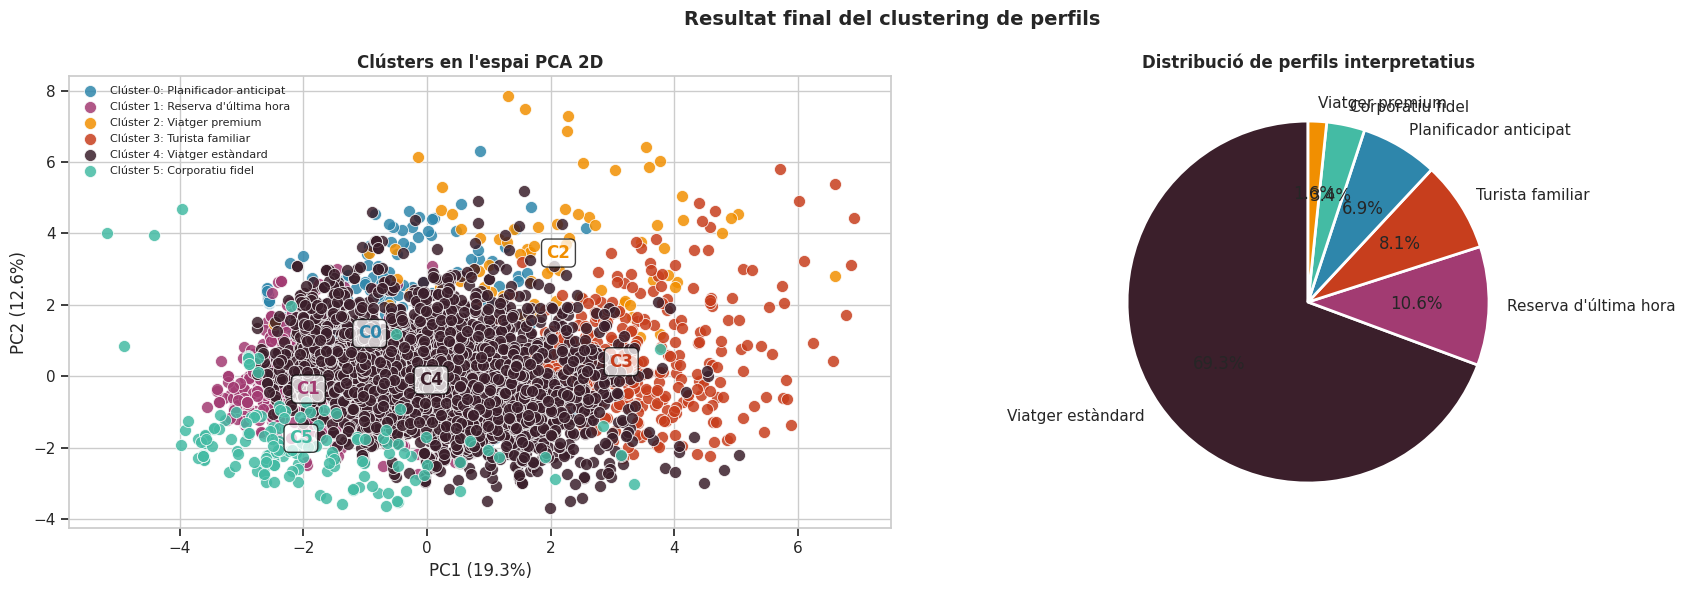

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
for cluster_id in sorted(df_model["cluster"].unique()):
    mask = df_model["cluster"] == cluster_id
    color = PALETTE[int(cluster_id) % len(PALETTE)]
    label = cluster_labels[cluster_id]
    ax.scatter(
        X_pca2[mask, 0],
        X_pca2[mask, 1],
        s=75,
        alpha=0.85,
        color=color,
        edgecolors="white",
        linewidths=0.6,
        label=f"Clúster {cluster_id}: {label}",
    )
    centroid_x = X_pca2[mask, 0].mean()
    centroid_y = X_pca2[mask, 1].mean()
    ax.annotate(
        f"C{cluster_id}",
        (centroid_x, centroid_y),
        fontsize=12,
        fontweight="bold",
        color=color,
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "alpha": 0.75},
    )

ax.set_title("Clústers en l'espai PCA 2D", fontweight="bold")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.legend(fontsize=8)

ax2 = axes[1]
profile_counts = df_model["profile_label"].value_counts()
profile_colors = [
    PALETTE[int(df_model.loc[df_model["profile_label"] == profile, "cluster"].iloc[0]) % len(PALETTE)]
    for profile in profile_counts.index
]
ax2.pie(
    profile_counts.values,
    labels=profile_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=profile_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax2.set_title("Distribució de perfils interpretatius", fontweight="bold")

plt.suptitle("Resultat final del clustering de perfils", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 18. Anàlisi addicional: estabilitat interna mitjançant Silhouette

S'afegeix una visualització dels valors Silhouette per observació per comprovar la cohesió interna dels clústers del model final. Aquest gràfic ajuda a detectar si algun clúster queda menys definit que la resta.


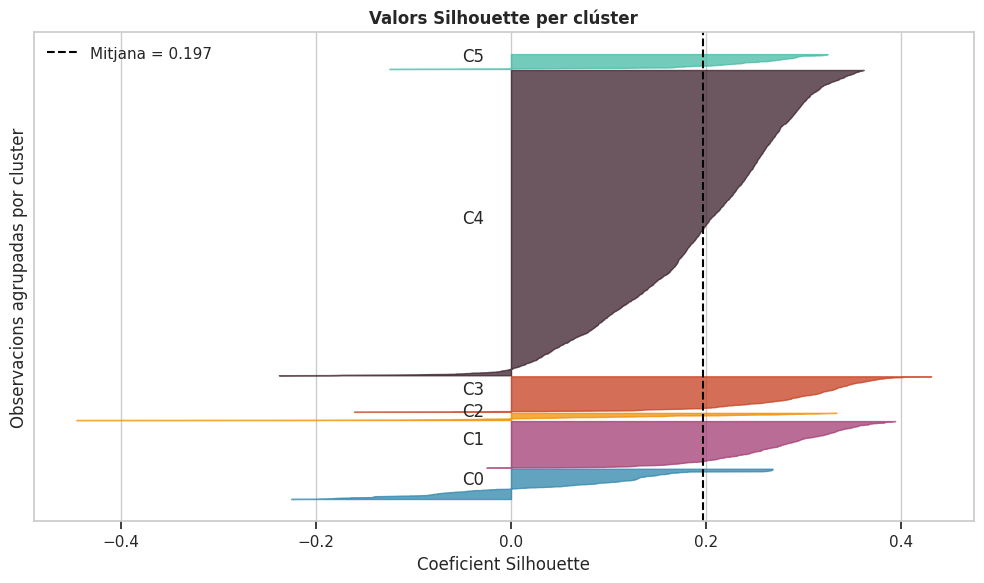

In [67]:
sample_silhouette_values = silhouette_samples(X, best_labels)
average_silhouette = silhouette_score(X, best_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for cluster_id in sorted(np.unique(best_labels)):
    cluster_silhouette_values = sample_silhouette_values[best_labels == cluster_id]
    cluster_silhouette_values.sort()

    size_cluster = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster
    color = PALETTE[int(cluster_id) % len(PALETTE)]

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.75,
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f"C{cluster_id}")
    y_lower = y_upper + 10

ax.axvline(average_silhouette, color="black", linestyle="--", label=f"Mitjana = {average_silhouette:.3f}")
ax.set_title("Valors Silhouette per clúster", fontweight="bold")
ax.set_xlabel("Coeficient Silhouette")
ax.set_ylabel("Observacions agrupadas por cluster")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

## 19. Variables més discriminants entre clústers

S'entrena un Random Forest auxiliar per estimar quines variables ajuden més a diferenciar els clústers. Aquest model no forma part del clustering; s'utilitza únicament com a suport interpretatiu.


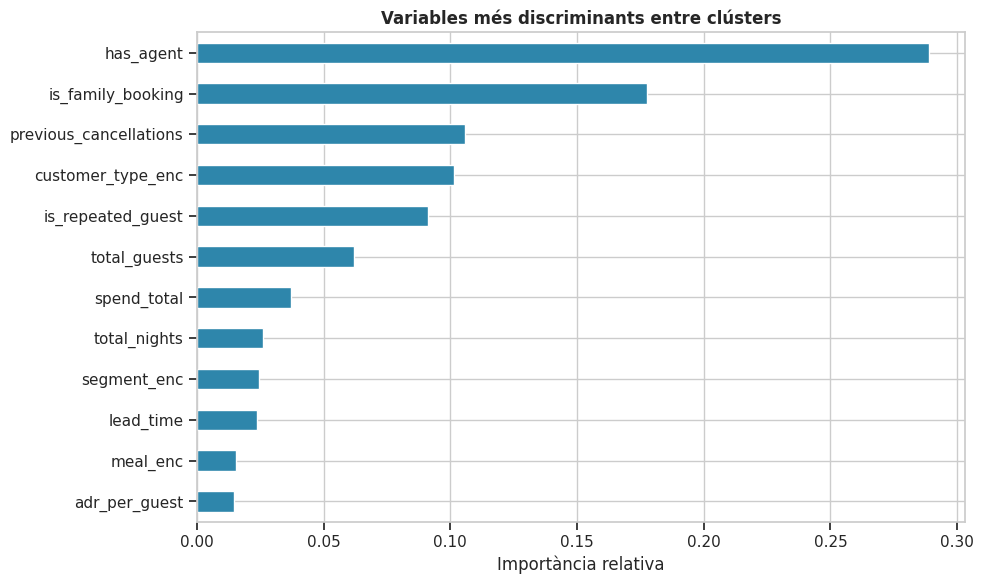

,importància
has_agent,0.288824
is_family_booking,0.177637
previous_cancellations,0.105927
customer_type_enc,0.101584
is_repeated_guest,0.091110
total_guests,0.061853
spend_total,0.036963
total_nights,0.026197
segment_enc,0.024522
lead_time,0.023517


In [68]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X, best_labels)

feature_importance = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.head(12).sort_values().plot(
    kind="barh",
    ax=ax,
    color=PALETTE[0],
    edgecolor="white",
)
ax.set_title("Variables més discriminants entre clústers", fontweight="bold")
ax.set_xlabel("Importància relativa")
plt.tight_layout()
plt.show()

display(feature_importance.head(12).rename("importància").to_frame())

## 20. Taula resum final de perfils

La taula resumeix la mida, el comportament mitjà i les característiques predominants de cada clúster. Aquesta taula és descriptiva i serveix per redactar la interpretació dels perfils.


In [69]:
summary_rows = []

for cluster_id in sorted(df_model["cluster"].unique()):
    subset = df_model[df_model["cluster"] == cluster_id]
    summary_rows.append({
        "cluster": cluster_id,
        "perfil_interpretatiu": cluster_labels[cluster_id],
        "n_reserves": len(subset),
        "percentatge": f"{len(subset) / len(df_model):.1%}",
        "lead_time_mitja": f"{subset['lead_time'].mean():.0f} dies",
        "nits_mitjanes": f"{subset['total_nights'].mean():.1f}",
        "hostes_mitjans": f"{subset['total_guests'].mean():.1f}",
        "adr_mitja_per_hoste": f"{subset['adr_per_guest'].mean():.1f}",
        "despesa_total_mitjana": f"{subset['spend_total'].mean():.0f}",
        "peticions_especials_mitjanes": f"{subset['total_of_special_requests'].mean():.1f}",
        "hotel_predominant": subset["hotel"].mode().iloc[0],
        "segment_predominant": subset["market_segment"].mode().iloc[0],
        "tipus_client_predominant": subset["customer_type"].mode().iloc[0],
        "risc_pais_predominant": subset["country_risk"].mode().iloc[0],
    })

summary = pd.DataFrame(summary_rows)
display(summary)

,cluster,perfil_interpretatiu,n_reserves,percentatge,lead_time_mitja,nits_mitjanes,hostes_mitjans,adr_mitja_per_hoste,despesa_total_mitjana,peticions_especials_mitjanes,hotel_predominant,segment_predominant,tipus_client_predominant,risc_pais_predominant
0,0,Planificador anticipat,326,6.9%,160 dies,3.9,1.9,44.9,314,0.4,City Hotel,Offline TA/TO,Contract,High
1,1,Reserva d'última hora,502,10.6%,58 dies,2.3,1.6,55.8,195,0.2,Resort Hotel,Direct,Transient,High
2,2,Viatger premium,78,1.6%,147 dies,12.7,2.0,67.9,1501,0.9,Resort Hotel,Online TA,Transient,Low
3,3,Turista familiar,383,8.1%,90 dies,3.9,3.4,45.1,595,0.8,City Hotel,Online TA,Transient,Low
4,4,Viatger estàndard,3280,69.3%,105 dies,3.3,1.9,55.8,339,0.6,City Hotel,Online TA,Transient,Low
5,5,Corporatiu fidel,161,3.4%,33 dies,1.7,1.5,46.5,121,0.6,City Hotel,Corporate,Transient,High


## 21. Exportació del resultat

S'exporta un CSV amb totes les columnes originals del dataset i una única columna addicional: `cluster`. No s'hi afegeixen variables derivades, etiquetes interpretatives ni mètriques auxiliars.


In [70]:
df_output = df.copy()
df_output["cluster"] = df_model["cluster"].astype(int).values

df_output.to_csv(OUTPUT_PATH, index=False)

print(f"Fitxer exportat: {OUTPUT_PATH}")
print(f"Dimensions del fitxer exportat: {df_output.shape}")
print("Columnes afegides respecte al dataset original: ['cluster']")
display(df_output.head())

Fitxer exportat: hotel_clustering_output.csv
Dimensions del fitxer exportat: (4730, 23)
Columnes afegides respecte al dataset original: ['cluster']


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,gender_account,meal,market_segment,distribution_channel,is_repeated_guest,...,customer_type,total_of_special_requests,has_agent,has_company,total_nights,total_guests,adr_per_guest,is_family_booking,country_risk,cluster
0,Resort Hotel,203,2016,December,2,Female,BB,Direct,Direct,0,...,Transient,0,1,0,7,2.0,33.40,0,Low,4
1,City Hotel,82,2015,July,16,Female,BB,Online TA,TA/TO,0,...,Transient,0,1,0,3,2.0,38.25,0,High,4
2,City Hotel,25,2016,December,27,Female,BB,Offline TA/TO,TA/TO,0,...,Transient-Party,1,1,0,3,3.0,20.00,0,Medium,4
3,City Hotel,1,2016,March,9,Female,BB,Online TA,TA/TO,0,...,Transient-Party,0,1,0,1,1.0,95.00,0,Low,4
4,City Hotel,70,2017,April,16,Female,SC,Online TA,TA/TO,0,...,Transient,0,1,0,4,2.0,54.00,0,Low,4


## 22. Resum metodològic

S'ha realitzat un clustering de reserves hoteleres a partir de variables relacionades amb la planificació, la durada de l'estada, el valor econòmic, el canal, el tipus de client, l'historial i la complexitat de la reserva.

El procediment seguit permet obtenir grups interpretables que poden utilitzar-se posteriorment com a perfils TLP dins de l'IDSS. Tanmateix, el fitxer final es manté net: només incorpora la columna `cluster`, de manera que qualsevol assignació posterior de noms de perfil, regles d'actuació o recomanacions pugui fer-se en mòduls separats del sistema.
